In [73]:
# Ingestion code from 04b analysis file
import pandas as pd
import numpy as np
import ast

def parse_census_tracts(tract_str):
    """
    Parse census tract string from incidents file.
    Input: string like "['410']" or "['15.03']" or "['2.04', '2.03']"
    Returns: list of tract codes, or empty list if parsing fails
    """
    if pd.isna(tract_str) or tract_str == '':
        return []
    try:
        # Remove any whitespace
        tract_str = str(tract_str).strip()
        # Try to evaluate as Python literal
        tracts = ast.literal_eval(tract_str)
        if isinstance(tracts, str):
            return [tracts]
        elif isinstance(tracts, list):
            return [str(t) for t in tracts]
        else:
            return []
    except:
        return []

def load_data():
    """Load incident and census demographic data"""
    print("\nLoading data...")
    
    # Load structure fire incidents with census tracts
    incidents = pd.read_csv("../processed_data/sf_incidents_with_tracts.csv")
    print(f"  Structure fire incidents: {len(incidents):,}")
    
    # Parse census tract column
    incidents['tract_list'] = incidents['tract_codes'].apply(parse_census_tracts)
    
    # Check coverage
    has_tract = incidents['tract_list'].apply(len) > 0
    print(f"  Incidents with tract data: {has_tract.sum():,} ({has_tract.sum()/len(incidents)*100:.1f}%)")
    
    # Load census demographics
    pop_data = pd.read_csv("../raw_data/census_population.csv", dtype={'tract': str})
    print(f"  Census tracts with population: {len(pop_data)}")
    
    housing_data = pd.read_csv("../raw_data/census_housing.csv", dtype={'tract': str})
    print(f"  Census tracts with housing: {len(housing_data)}")
    
    age_data = pd.read_csv("../raw_data/census_year_built.csv", dtype={'tract': str})
    print(f"  Census tracts with building age: {len(age_data)}")
    
    return incidents, pop_data, housing_data, age_data

def prepare_census_demographics(pop_data, housing_data, age_data):
    """
    Merge census demographic files into a single dataframe by tract code.
    """
    print("\nPreparing census demographics...")
    
    # Standardize tract column names and format
    pop_data = pop_data.rename(columns={'Total population': 'population', 'tract': 'tract_code'})
    housing_data = housing_data.rename(columns={'Total': 'total_units', 'tract': 'tract_code'})
    age_data = age_data.rename(columns={'Total': 'total_units_age', 'tract': 'tract_code'})
    
    # Convert tract codes to strings
    pop_data['tract_code'] = pop_data['tract_code'].astype(str)
    housing_data['tract_code'] = housing_data['tract_code'].astype(str)
    age_data['tract_code'] = age_data['tract_code'].astype(str)
    
    # Merge population with housing
    census = pop_data[['tract_code', 'population']].merge(
        housing_data[['tract_code', 'total_units', '1-unit, detached', '1-unit, attached']],
        on='tract_code', how='outer'
    )
    
    # Merge with building age
    census = census.merge(
        age_data[['tract_code', 'total_units_age', 'Built 2010-2019', 'Built 2020 or later', 'Built 1939 or earlier']],
        on='tract_code', how='outer'
    )
    
    # Calculate single-family percentage
    census['single_family_units'] = (
        census['1-unit, detached'].fillna(0) + census['1-unit, attached'].fillna(0)
    )
    census['pct_single_family'] = np.where(
        census['total_units'] > 0,
        census['single_family_units'] / census['total_units'] * 100,
        np.nan
    )
    
    # Calculate building age percentages
    census['pct_built_2010_plus'] = np.where(
        census['total_units_age'] > 0,
        (census['Built 2010-2019'].fillna(0) + census['Built 2020 or later'].fillna(0)) / 
        census['total_units_age'] * 100,
        np.nan
    )
    
    census['pct_built_pre1970'] = np.where(
        census['total_units_age'] > 0,
        census['Built 1939 or earlier'].fillna(0) / census['total_units_age'] * 100,
        np.nan
    )
    
    print(f"  Census tracts in demographics: {len(census)}")
    
    return census

def explode_incidents_by_tract(incidents_df, census_df):
     ### Since we're exploding by tract, we need to make sure to average out the census demographics in the case of boundaries.
    """
    Create one row per incident-tract combination.
    For incidents in multiple tracts, duplicate the row.
    """
    print("\nExploding incidents by tract...")
    
    # Create list of incident-tract pairs
    pairs = []
    for idx, row in incidents_df.iterrows():
        tracts = row['tract_list']
        if len(tracts) > 0:
            for tract in tracts:
                pairs.append({**row.to_dict(), 'tract_code': tract})
    
    # Convert to dataframe
    exploded = pd.DataFrame(pairs)
    print(f"  Incident-tract pairs: {len(exploded):,}")

    exploded = exploded.merge(
        census_df[['tract_code', 'population', 'total_units', 'pct_single_family', 
                        'pct_built_2010_plus', 'pct_built_pre1970']],
        on='tract_code',
        how='left'
    )
    
    matched = exploded['population'].notna().sum()
    print(f"  Incidents with census data: {matched:,} ({matched/len(exploded)*100:.1f}%)")
    
    if matched < len(exploded) * 0.1:  # If match rate is still low, try simpler approach
        print(f"  Match rate low - checking available tracts in data...")
        print(f"    Unique incident tracts: {exploded['tract_code'].nunique()}")
        print(f"    Unique census tracts: {census_df['tract_code'].nunique()}")
        print(f"    Sample incident codes: {exploded['tract_code'].unique()[:10]}")
        print(f"    Sample census codes: {census_df['tract_code'].unique()[:10]}")
    
    return exploded

In [76]:
incidents, pop_data, housing_data, age_data = load_data()

# Prepare census demographics
census = prepare_census_demographics(pop_data, housing_data, age_data)
# Weight incidents by number of tracts they touch.
incidents['num_touching_tracts'] = incidents['tract_list'].apply(len)
# Explode incidents by tract and join with demographics
incidents_by_tract = explode_incidents_by_tract(incidents, census)




Loading data...
  Structure fire incidents: 3,176
  Incidents with tract data: 3,176 (100.0%)
  Census tracts with population: 471
  Census tracts with housing: 471
  Census tracts with building age: 471

Preparing census demographics...
  Census tracts in demographics: 471

Exploding incidents by tract...
  Incident-tract pairs: 3,255
  Incidents with census data: 3,255 (100.0%)


In [78]:
incidents_by_tract[incidents_by_tract['num_touching_tracts'] > 1].head()

,incident_number,calendaryear,month,incdate,call_type,problem,responsearea,prioritydescription,council_district,location,...,census_tracts,tract_codes,tract_list,num_touching_tracts,tract_code,population,total_units,pct_single_family,pct_built_2010_plus,pct_built_pre1970
34,22003662,2022,Jan,01/07/2022 12:00:00 AM,Fire,BOXL- Structure Fire,00-0303,1F,9,"(-97.741431,30.304425)",...,"['2.04', '2.03']","['000204', '000203']","[000204, 000203]",2,000204,2593,1560,57.564103,4.358974,27.884615
35,22003662,2022,Jan,01/07/2022 12:00:00 AM,Fire,BOXL- Structure Fire,00-0303,1F,9,"(-97.741431,30.304425)",...,"['2.04', '2.03']","['000204', '000203']","[000204, 000203]",2,000203,3020,1112,1.708633,37.679856,0.989209
55,22007278,2022,Jan,01/15/2022 12:00:00 AM,Fire,BOX -Structure Fire,00-2203,1F,3,"(-97.717205,30.237520)",...,"['23.24', '23.26']","['002324', '002326']","[002324, 002326]",2,002324,1247,619,0.000000,9.531502,0.000000
56,22007278,2022,Jan,01/15/2022 12:00:00 AM,Fire,BOX -Structure Fire,00-2203,1F,3,"(-97.717205,30.237520)",...,"['23.24', '23.26']","['002324', '002326']","[002324, 002326]",2,002326,903,406,11.083744,14.039409,0.000000
71,22009976,2022,Jan,01/20/2022 12:00:00 AM,Fire,BOX -Structure Fire,05-4604,1F,-,"(-97.853297,30.178153)",...,"['313', '319']","['031300', '031900']","[031300, 031900]",2,031300,3918,1936,59.090909,19.266529,0.671488


In [86]:
tract_incidents = incidents_by_tract.groupby(['tract_code', 'pct_built_2010_plus']).size().reset_index(name='num_incidents')
tract_incidents.head()

,tract_code,pct_built_2010_plus,num_incidents
0,000101,14.747475,22
1,000102,6.506239,10
2,000203,37.679856,9
3,000204,4.358974,16
4,000205,17.786855,13


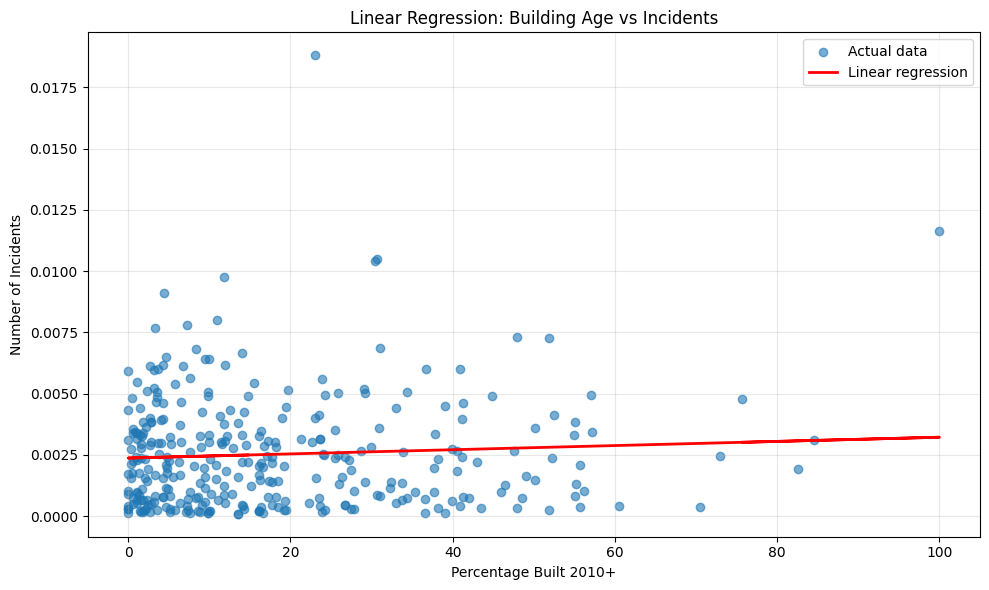

R-squared: 0.0043
Slope: 0.0000
Intercept: 0.0024


In [90]:
from sklearn.linear_model import LinearRegression
import numpy as np

import matplotlib.pyplot as plt

# Aggregate incidents by tract
tract_data = incidents_by_tract.groupby(
    ['tract_code', 'pct_built_2010_plus', 'population','total_units', 'num_touching_tracts']
    ).size().reset_index(name='num_incidents')

tract_data['incidents_per_capita'] = tract_data['num_incidents'] / tract_data['population']
tract_data['incidents_per_unit'] = tract_data['num_incidents'] / tract_data['total_units']


# Prepare data for regression
X = tract_data[['pct_built_2010_plus']].values
y = tract_data['incidents_per_capita'].values

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X, y, alpha=0.6, label='Actual data')
ax.plot(X, model.predict(X), color='red', linewidth=2, label='Linear regression')
ax.set_xlabel('Percentage Built 2010+')
ax.set_ylabel('Number of Incidents')
ax.set_title('Linear Regression: Building Age vs Incidents')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"R-squared: {model.score(X, y):.4f}")
print(f"Slope: {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

In [ ]:
# Next steps:
# Plot regression for incident rates per population.
# Plot multi-regression for different housing type buckets.